# Prac 1: Decomposition Practical (Additive and Mutiplication)

In [2]:
#Import Prackeges
import pandas as pd
import numpy as np
import os
import matplotlib.pyplot as plt
from statsmodels.tsa.seasonal import seasonal_decompose
import seaborn as sns

In [3]:
df = pd.read_csv(r"C:\Users\nmims.student\AFTS_LAB_28\catfish.csv")
df.head()

,Date,Total
0,1986-1-01,9034
1,1986-2-01,9596
2,1986-3-01,10558
3,1986-4-01,9002
4,1986-5-01,9239


In [4]:
df.tail()

,Date,Total
319,2012-8-01,14442
320,2012-9-01,13422
321,2012-10-01,13795
322,2012-11-01,13352
323,2012-12-01,12716


In [5]:
df.shape

(324, 2)

In [6]:
#Convert column in datetime format
df['Date'] = pd.to_datetime(df['Date'])
df = df.set_index('Date')

In [7]:
df.head()

,Total
Date,
1986-01-01,9034
1986-02-01,9596
1986-03-01,10558
1986-04-01,9002
1986-05-01,9239


Text(0, 0.5, 'Date')

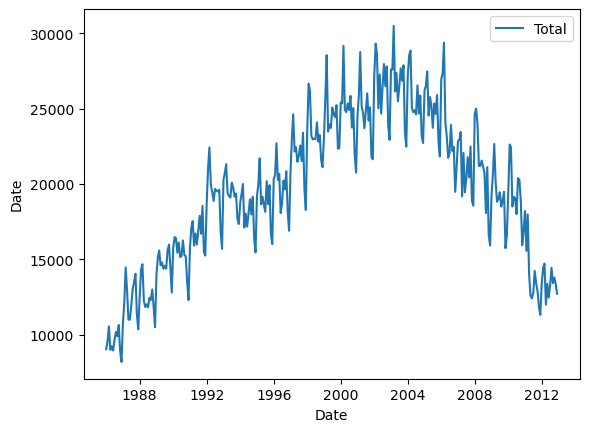

In [8]:
sns.lineplot(df)
plt.ylabel("Date")

In [9]:
#The pattern and trend are amplifying hence we will be using multiplicative model for decomposition

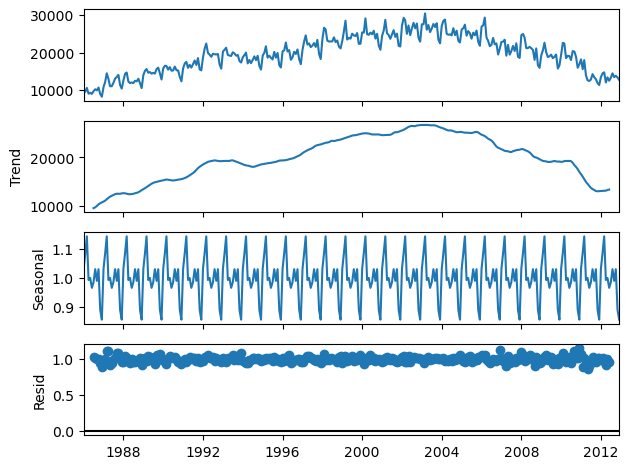

In [10]:
result = seasonal_decompose(df[['Total']], model = 'multiplicative',period = 12)
result.plot()
plt.show()

In [11]:
import pymannkendall as mk

#Perform Mann-kendall test
#H0: There is no monotonic trend in th series

mk.original_test(df['Total'])

Mann_Kendall_Test(trend='increasing', h=True, p=2.220446049250313e-16, z=8.196170484566949, Tau=0.30522111378664524, s=15971.0, var_s=3796539.0, slope=31.901026462002072, intercept=14508.484226386667)

In [12]:
#pvalue < 0.05 => reject H0. There is a Trend Present

In [45]:
train_df = df[:int(df.shape[0]*0.8)]
test_df = df[int(df.shape[0]*0.8):]

In [46]:
train_df.head()

,Total
Date,
1986-01-01,9034
1986-02-01,9596
1986-03-01,10558
1986-04-01,9002
1986-05-01,9239


In [47]:
#TRIPLE EXPONENTIAL SMOOTHING |HOLT WINTERS MODEL
from statsmodels.tsa.api import ExponentialSmoothing
#Create an instance of Exponential Smoothing loss
model_triple_mul = ExponentialSmoothing(train_df, seasonal_periods=12, trend='add', seasonal='add')
#Fit the model to the data
model_triple_fit_mul = model_triple_mul.fit()

C:\ProgramData\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)


In [48]:
model_triple_fit.params

{'smoothing_level': 0.4829502678817372,
 'smoothing_trend': 0.04565669701731081,
 'smoothing_seasonal': 0.1427188024737868,
 'damping_trend': nan,
 'initial_level': 9146.121080003231,
 'initial_trend': 120.22917891902814,
 'initial_seasons': array([  328.18436081,  1407.86000325,  2070.74668039,   267.89184145,
          -81.18867984,  -554.42611616,  -286.67265122,   130.9466019 ,
           20.91151766,   551.21876499, -1488.85074895, -2562.4225907 ]),
 'use_boxcox': False,
 'lamda': None,
 'remove_bias': False}

In [49]:
forecast_triple_mul = model_triple_fit_mul.forecast(len(test_df))

TypeError: 'str' object is not callable

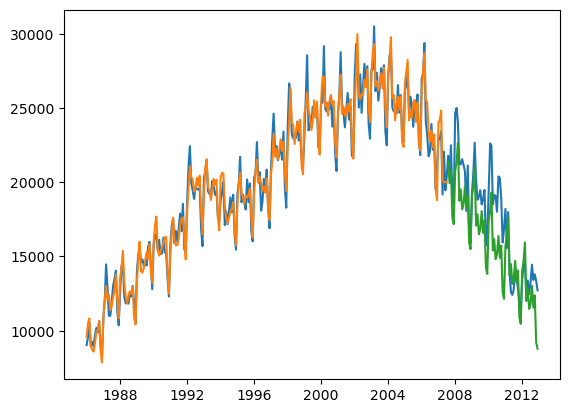

In [51]:
plt.plot(df, label='Original Data')
plt.plot(model_triple_fit_mul.fittedvalues, label='Fitted Values')
plt.plot(forecast_triple_mul , label='Forecast')
plt.xlabel('Year')
plt.ylabel('Number of Passengers')
plt.title('Triple Exponential Smoothing')
plt.legend()
plt.show()

In [52]:
#ADF Test
#Null Hypothesis (H0): Series is non Stationary, i.e, series has a unit root
#Alternate Hypoyhesis (H1) : Series is non-stationary, i.e, series has no unit root
#p-value > 0.05 - Reject Null Hypothesis (H0)